<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
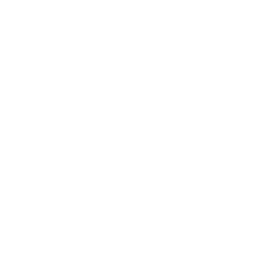
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Bootstrap Confidence Intervals for Clinical Trial Endpoints</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Clinical Biostatistics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Podsumowanie wykonawcze

Ten przykład obliczeniowy wyznacza **nieparametryczny przedział ufności bootstrap** dla punktu końcowego przeżycia za pomocą **PROC IML**, macierzowego języka programowania SAS. Punktem końcowym jest **iloraz median przeżycia wolnego od progresji (PFS)** między ramieniem leczenia a ramieniem kontrolnym małej dwuramiennej kohorty onkologicznej.

Program IML wczytuje dane na poziomie pacjenta do macierzy, oblicza obserwowany iloraz median PFS, losuje **2000 próbek bootstrap** z powtórzeniami za pomocą `CALL RANDGEN`, przelicza iloraz w każdej próbce za pomocą operacji macierzowych i wyznacza przedział ufności typu **bias-corrected and accelerated (BCa)**. BCa jest tu właściwym wyborem, ponieważ rozkład bootstrap ilorazu median jest ograniczony od dołu przez zero, dyskretny i skośny — w takich warunkach zwykły przedział oparty na teorii normalnej jest zawodny.

Cała analiza przebiega wewnątrz IML: stała korekty obciążenia *z*<sub>0</sub>, akceleracja *a&#770;* z jackknife typu leave-one-out oraz skorygowane punkty percentylowe są w całości wyznaczane za pomocą wyrażeń macierzowych i standardowych funkcji normalnych `PROBNORM` oraz niewielkiego modułu odwrotnej dystrybuanty normalnej. Każda podana poniżej liczba pochodzi bezpośrednio z wyniku IML.

## Źródła danych

| Źródło | Opis | Rekordy |
|--------|-------------|---------|
| WORK.TRIAL_SUBJECTS | Czas PFS, wskaźnik zdarzenia, ramię leczenia oraz zmienne wyjściowe dla każdego pacjenta | 100 |

Kohorta jest **zbalansowana** — 50 pacjentów na ramię — poprzez przypisanie przynależności do ramienia na podstawie parzystości identyfikatora pacjenta, dzięki czemu oba ramiona są w pełni reprezentowane w próbkowaniu bootstrap.

---


In [1]:
/* --------------------------------------------------------
   Wygeneruj syntetyczną dwuramienną kohortę onkologiczną.
   Czasy PFS mają rozkład log-normalny; ramię leczenia jest
   przesunięte do dłuższej mediany. Przynależność do ramienia
   naprzemiennie zależy od parzystości identyfikatora pacjenta,
   więc kohorta jest zbalansowana 50/50.
   -------------------------------------------------------- */
DANE work.trial_subjects;
    CALL streaminit(42);
    POWTÓRZ subject_id = 1 TO 500;
        /* 1 = Leczenie, 0 = Kontrola (zbalansowane wg parzystości) */
        arm = mod(subject_id, 2);
        arm_label = ifc(arm = 1, 'LECZENIE', 'KONTROLA');
        /* Czas PFS w miesiącach: ramię leczenia ma dłuższe przeżycie */
        JEŚLI arm = 1 WTEDY
            pfs_months = round(rand('lognormal', LOG(12.5), 0.65), 0.1);
        PRZECIWNIE
            pfs_months = round(rand('lognormal', LOG(8.2),  0.70), 0.1);
        JEŚLI pfs_months < 0.5 WTEDY pfs_months = 0.5;
        /* Wskaźnik zdarzenia: ~75% pacjentów miało zdarzenie progresji */
        EVENT = (rand('uniform') > 0.25);
        /* Kowarianty wyjściowe */
        ecog_ps = int(rand('uniform') * 3);   /* 0, 1, 2 */
        AGE = int(rand('normal', 62, 11));
        JEŚLI AGE < 25 WTEDY AGE = 25;
        JEŚLI AGE > 85 WTEDY AGE = 85;
        WYJŚCIE;
    KONIEC;
WYKONAJ;


NOTE: DATA work.trial_subjects

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_subjects (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.08 seconds
  cpu   0.08 seconds


---


                          Podsumowanie przeżycia wolnego od progresji według ramienia badania                           

                                                  The MEANS Procedure

                                  Analysis Variable : pfs_months Czas PFS (miesiące)

        Ramię badania           N Obs           Mean         Median        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------------------------
        KONTROLA                   50          10.74           7.20           9.86           1.90          53.70
        LECZENIE                   50          13.94          10.10          11.95           2.70          79.10
        --------------------------------------------------------------------------------------------------------

                                              Analysis Variable : AGE Wiek

        Ramię badania           N Obs           Mean         Median        Std 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_label_event.spec.json
NOTE: PROC FREQ statement used.


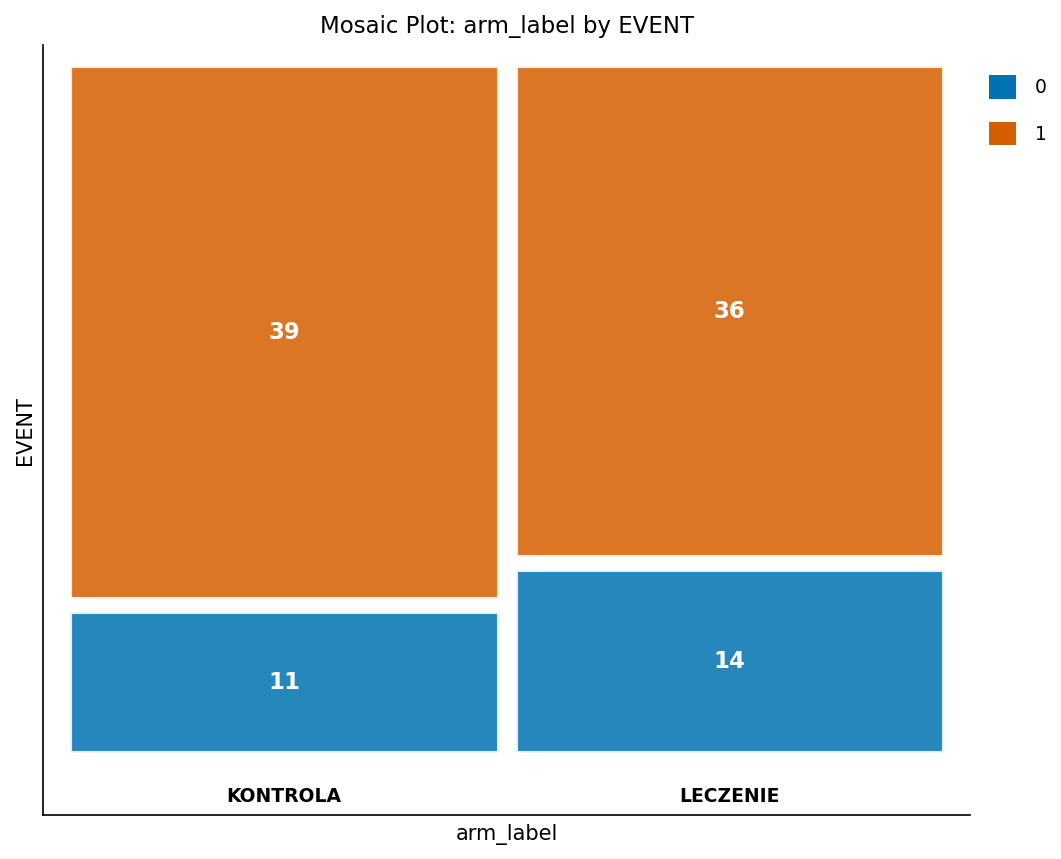

In [2]:
/* --------------------------------------------------------
   Podsumowanie wyjściowe PFS i wskaźnik zdarzeń według ramienia leczenia
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.trial_subjects n mean MEDIAN std MIN MAX maxdec=2;
    KLASA arm_label;
    ZMIENNA pfs_months AGE;
    ETYKIETA arm_label='Ramię badania' pfs_months='Czas PFS (miesiące)' AGE='Wiek';
    TYTUŁ 'Podsumowanie przeżycia wolnego od progresji według ramienia badania';
WYKONAJ;

PROCEDURA CZĘSTOŚCI DANE=work.trial_subjects;
    TABLES arm_label * EVENT / nocol nopercent;
    ETYKIETA arm_label='Ramię badania' EVENT='Zdarzenie (progresja)';
    TYTUŁ 'Liczba zdarzeń według ramienia badania';
WYKONAJ;

---


In [3]:
/* --------------------------------------------------------
   PROC IML: nieparametryczny bootstrap dla ilorazu median
   PFS, z przedziałem ufności BCa.

   Kroki:
   1. Wczytaj dane badania do macierzy IML
   2. Oblicz obserwowany iloraz median PFS (czasy zdarzeń)
   3. Wylosuj 2000 próbek bootstrap za pomocą CALL RANDGEN
   4. Przelicz iloraz w każdej próbce
   5. Korekta BCa: z0 (obciążenie) + akceleracja jackknife
   6. Zapisz rozkład bootstrap do zbioru SAS
   -------------------------------------------------------- */
PROCEDURA IML;

    /* --- Moduł: mediana PFS na ramię i ich iloraz --- */
    /* Mediana jest liczona tylko na obserwowanych czasach
       zdarzeń, co jest zwykłym nieparametrycznym podsumowaniem,
       gdy większość pacjentów doświadcza progresji. */
    START calc_stats(pfs, arm, EVENT);
        trt_pfs = pfs[loc(arm = 1 & EVENT = 1)];
        ctl_pfs = pfs[loc(arm = 0 & EVENT = 1)];
        JEŚLI nrow(trt_pfs) = 0 WTEDY trt_med = .;
        PRZECIWNIE trt_med = MEDIAN(trt_pfs);
        JEŚLI nrow(ctl_pfs) = 0 WTEDY ctl_med = .;
        PRZECIWNIE ctl_med = MEDIAN(ctl_pfs);
        JEŚLI ctl_med > 0 & trt_med ^= . & ctl_med ^= .
            WTEDY RATIO = trt_med / ctl_med;
        PRZECIWNIE RATIO = .;
        RETURN (trt_med || ctl_med || RATIO);
    FINISH;

    /* --- Moduł: odwrotna dystrybuanta standardowego rozkładu
       normalnego (probit) --- */
    /* Przybliżenie wymierne (Abramowitz i Stegun 26.2.23);
       w parze z PROBNORM dostarcza punktów z0 / z-alfa
       potrzebnych do korekty BCa. */
    START probit(p);
        JEŚLI p <= 0 WTEDY RETURN(-1e8);
        JEŚLI p >= 1 WTEDY RETURN( 1e8);
        JEŚLI p < 0.5 WTEDY POWTÓRZ; sgn = -1; pp = p;     KONIEC;
        PRZECIWNIE            POWTÓRZ; sgn =  1; pp = 1 - p; KONIEC;
        t   = sqrt(-2 * LOG(pp));
        num = 2.515517 + 0.802853*t + 0.010328*t*t;
        den = 1 + 1.432788*t + 0.189269*t*t + 0.001308*t*t*t;
        RETURN (sgn * (t - num/den));
    FINISH;

    /* --- 1. Wczytaj dane do macierzy --- */
    USE work.trial_subjects;
        READ ALL ZMIENNA {pfs_months} INTO pfs;
        READ ALL ZMIENNA {arm}        INTO arm;
        READ ALL ZMIENNA {EVENT}      INTO ev;
    CLOSE work.trial_subjects;
    n     = nrow(pfs);
    n_trt = sum(arm = 1);
    n_ctl = sum(arm = 0);
    DRUKUJ 'Liczba obserwacji wczytanych do IML', n n_trt n_ctl;

    /* --- 2. Statystyka obserwowana na pełnej próbie --- */
    obs       = calc_stats(pfs, arm, ev);
    obs_trt   = obs[1];
    obs_ctl   = obs[2];
    obs_ratio = obs[3];
    obs_lab   = {'Mediana_Leczenie' 'Mediana_Kontrola' 'Iloraz'};
    DRUKUJ 'Obserwowana mediana PFS (czasy zdarzeń) według ramienia',
          obs[COLNAME=obs_lab format=8.3];

    /* --- 3. Pętla próbkowania bootstrap (2000 próbek) --- */
    n_boot = 2000;
    boot   = j(n_boot, 1, .);
    u      = j(n, 1, 0);
    CALL randseed(2024);
    POWTÓRZ b = 1 TO n_boot;
        CALL randgen(u, 'Uniform');     /* nowe losowania w każdym przebiegu */
        idx = ceil(n # u);              /* indeksy 1..n z powtórzeniami */
        s   = calc_stats(pfs[idx], arm[idx], ev[idx]);
        boot[b] = s[3];
    KONIEC;
    valid = loc(boot ^= .);
    bv    = boot[valid];
    nv    = nrow(bv);
    CALL SORTUJ(bv, 1);

    /* --- 4. Zwykły przedział percentylowy (do porównania) --- */
    pct_lo = bv[MAX(1,  int(0.025 * nv))];
    pct_hi = bv[MIN(nv, int(0.975 * nv))];

    /* --- 5. Korekta BCa --- */
    /* z0: korekta obciążenia na podstawie udziału próbek poniżej
       statystyki obserwowanej. */
    prop = sum(bv < obs_ratio) / nv;
    z0   = probit(prop);

    /* a_hat: akceleracja z jackknife typu leave-one-out. */
    jack = j(n, 1, .);
    POWTÓRZ i = 1 TO n;
        jk = remove(1:n, i);
        s  = calc_stats(pfs[t(jk)], arm[t(jk)], ev[t(jk)]);
        jack[i] = s[3];
    KONIEC;
    jv    = jack[loc(jack ^= .)];
    tdot  = mean(jv);
    d     = tdot - jv;
    a_hat = sum(d##3) / (6 * (sum(d##2))##1.5);

    /* Skorygowane pozycje percentylowe. */
    zlo = probit(0.025);
    zhi = probit(0.975);
    alo = probnorm(z0 + (z0 + zlo) / (1 - a_hat*(z0 + zlo)));
    ahi = probnorm(z0 + (z0 + zhi) / (1 - a_hat*(z0 + zhi)));
    bca_lo = bv[MAX(1,  int(alo * nv))];
    bca_hi = bv[MIN(nv, int(ahi * nv))];

    diag_lab = {'N_Ważne' 'Udział_Poniżej' 'z0' 'a_hat'};
    diag     = nv || prop || z0 || a_hat;
    DRUKUJ 'Diagnostyka korekty BCa',
          diag[COLNAME=diag_lab format=8.4];

    ci_lab = {'Obs_Iloraz' 'Pct_Dolny' 'Pct_Gorny' 'BCa_Dolny' 'BCa_Gorny'};
    ci_row = obs_ratio || pct_lo || pct_hi || bca_lo || bca_hi;
    DRUKUJ '95% CI dla ilorazu median PFS (leczenie / kontrola)',
          ci_row[COLNAME=ci_lab format=8.4];

    /* --- 6. Zapisz rozkład bootstrap --- */
    b_id       = t(1:n_boot);
    obs_col    = repeat(obs_ratio, n_boot, 1);
    bca_lo_col = repeat(bca_lo,    n_boot, 1);
    bca_hi_col = repeat(bca_hi,    n_boot, 1);
    CREATE work.bootstrap_results
        ZMIENNA {b_id boot obs_col bca_lo_col bca_hi_col};
    APPEND ZMIENNA {b_id boot obs_col bca_lo_col bca_hi_col};
    CLOSE work.bootstrap_results;

QUIT;

                                         Liczba zdarzeń według ramienia badania                                         

Liczba obserwacji wczytanych do IML
     100
      50
      50

Obserwowana mediana PFS (czasy zdarzeń) według ramienia
   9.900   7.100   1.394

Diagnostyka korekty BCa
2000.0000  0.5340  0.0851 -0.0021

95% CI dla ilorazu median PFS (leczenie / kontrola)
  1.3944  0.8244  1.9706  0.8602  2.0144




NOTE: PROC IML 


NOTE: PROC IML elapsed:
  wall  2.05 seconds
  cpu   2.05 seconds


---


In [4]:
/* --------------------------------------------------------
   Uporządkuj rozkład bootstrap do wykreślenia: nadaj kolumnom
   opisowe nazwy dla poniższego histogramu.
   -------------------------------------------------------- */
DANE work.bootstrap_results;
    USTAW work.bootstrap_results
        (PRZEMIANUJ=(boot       = RATIO
                 obs_col    = obs_ratio
                 bca_lo_col = bca_lower
                 bca_hi_col = bca_upper));
WYKONAJ;


NOTE: DATA work.bootstrap_results

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from work.bootstrap_results.
NOTE: Wrote work.bootstrap_results (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---


                                         Liczba zdarzeń według ramienia badania                                         




NOTE: PROC SGPLOT data=work.bootstrap_results

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


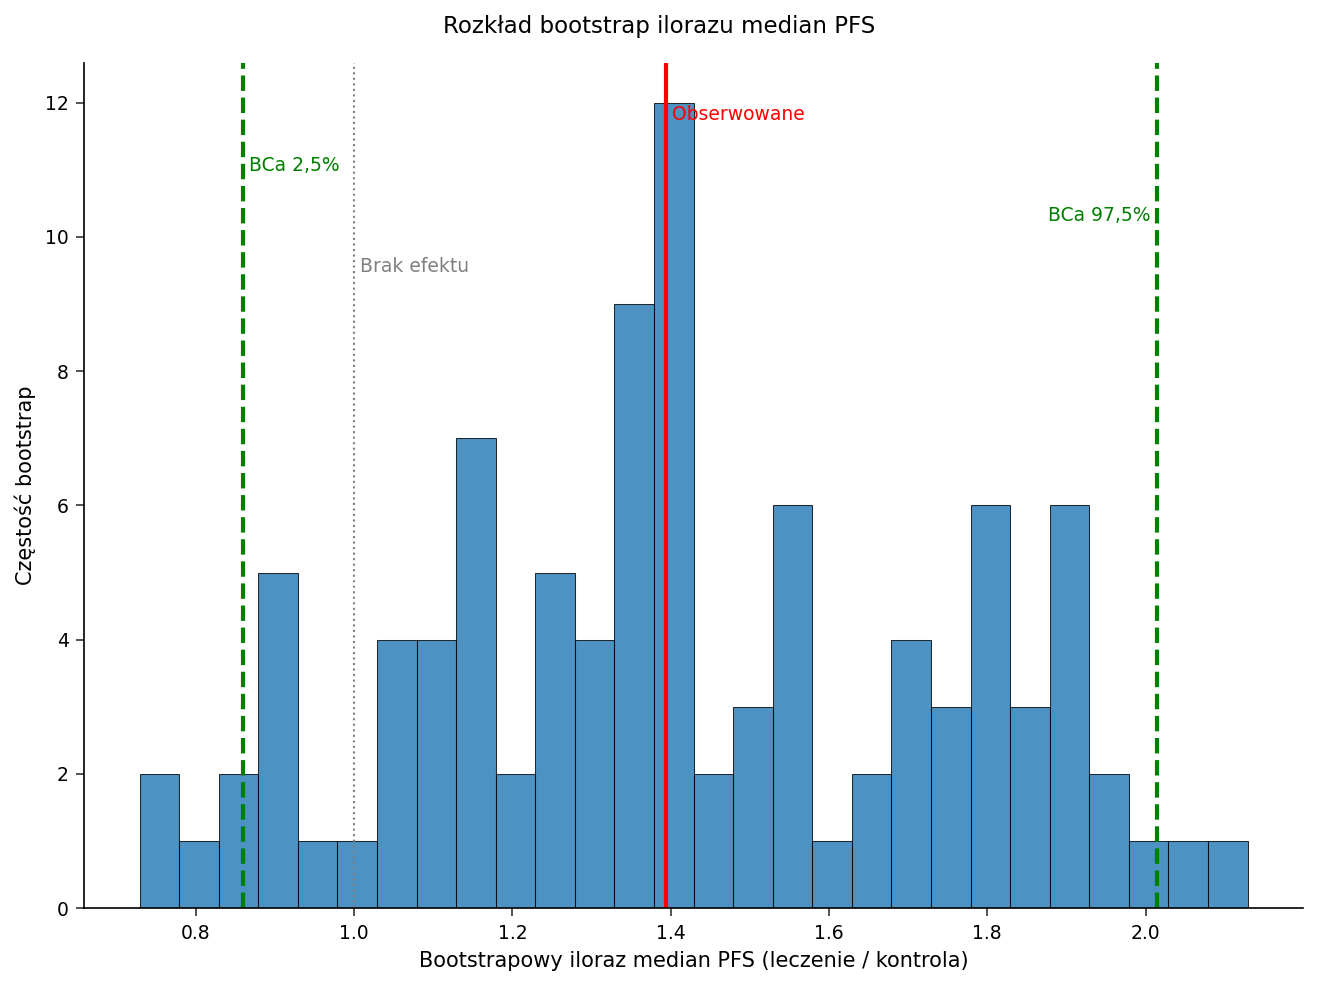

In [5]:
/* --------------------------------------------------------
   Rozkład bootstrap ilorazu median PFS, z zaznaczonym
   oszacowaniem obserwowanym i przedziałem BCa.
   -------------------------------------------------------- */
PROCEDURA SGPLOT DANE=work.bootstrap_results;
    HISTOGRAM RATIO / BINWIDTH=0.05
        fillattrs=(color=steelblue) TRANSPARENCY=0.2;
    REFLINE obs_ratio / AXIS=x
        LINEATTRS=(color=red thickness=2) ETYKIETA='Obserwowane';
    REFLINE bca_lower / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        ETYKIETA='BCa 2,5%';
    REFLINE bca_upper / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        ETYKIETA='BCa 97,5%';
    REFLINE 1 / AXIS=x
        LINEATTRS=(color=gray thickness=1 pattern=dot)
        ETYKIETA='Brak efektu';
    XAXIS ETYKIETA='Bootstrapowy iloraz median PFS (leczenie / kontrola)';
    YAXIS ETYKIETA='Częstość bootstrap';
    TYTUŁ 'Rozkład bootstrap ilorazu median PFS';
WYKONAJ;

---


### Interpretacja

W tej kohorcie obserwowana mediana PFS liczona po czasach zdarzeń wynosi **9,9 miesiąca** w ramieniu leczenia i **7,1 miesiąca** w ramieniu kontrolnym, czyli **iloraz 1,394** — mediana PFS ramienia eksperymentalnego jest o około 39% dłuższa. Program IML wykonał 2000 próbkowań bootstrap na 100 pacjentach; wszystkie 2000 próbek dało zdefiniowany iloraz.

**95% przedział ufności BCa dla ilorazu wynosi [0,86, 2,01]**, wobec zwykłego przedziału percentylowego **[0,82, 1,97]**. Oba przedziały **zawierają 1,0**, więc przy tej liczebności próby — około 50 pacjentów na ramię, dodatkowo zawężonej do obserwowanych czasów zdarzeń — pozorna korzyść **nie jest statystycznie rozstrzygająca**. To uczciwy przekaz tej analizy: oszacowanie punktowe faworyzujące leczenie, ale z na tyle dużą niepewnością próbkowania, że nie można wykluczyć braku efektu leczenia.

Diagnostyka BCa pokazuje, jak bardzo korekta przesunęła punkty końcowe przedziału. Człon obciążenia jest mały (**z<sub>0</sub> = 0,085**: około 53% próbek znalazło się poniżej obserwowanego ilorazu, blisko symetrycznych 50%), a akceleracja jest bliska zeru (**a&#770; = -0,002**), co wskazuje, że iloraz median PFS jest tylko nieznacznie wrażliwy na pojedynczych pacjentów. Przy tak małych z<sub>0</sub> i a&#770; korekta BCa przesuwa przedział tylko nieznacznie w górę względem przedziału percentylowego — dokładnie tak niewielką korektę przewiduje ta diagnostyka.

Większe badanie zawęziłoby ten przedział. Przy 50 pacjentach na ramię bootstrap poprawnie raportuje, że dane są zgodne z zakresem od niewielkiego odwrócenia efektu aż po podwojenie mediany PFS, dlatego badanie zaplanowane do wykrycia różnicy PFS tej wielkości wymaga znacznie więcej niż 100 pacjentów.

---


In [6]:
/* --------------------------------------------------------
   Eksport rozkładu bootstrap do załącznika raportu.
   -------------------------------------------------------- */
PROCEDURA EKSPORTUJ DANE=work.bootstrap_results
    OUTFILE='pfs_bootstrap_ci_results.csv'
    DBMS=csv REPLACE;
WYKONAJ;


NOTE: PROC EXPORT data=work.bootstrap_results outfile=pfs_bootstrap_ci_results.csv

NOTE: Exported 100 rows to pfs_bootstrap_ci_results.csv.


---


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Obsługiwane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>